In [10]:
import utils
import numpy as np
import pandas as pd
import os
import re

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [11]:
# Preparation
dataset = 'TUS' # TUS, joystick, speakup, africa

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if dataset == 'TUS' or dataset == 'joystick':
    raw_output_path = '/Volumes/project/3025011.02/raw'
    unique_subject_ids = [52, 53] #[52, 53, 54, 55, 57]
    unique_sessions = [2, 3, 4]
elif dataset == 'pilot':
    raw_output_path = '/Volumes/project/3025011.02/long_experiment_data/phd_1_task/experiment_output'
    unique_subject_ids = [5]#[5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
    unique_sessions = [2, 3, 4]
elif dataset=='speakup':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/SpeakUp!2.0/experiment_output'
    unique_subject_ids = [2]#[2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25]
    unique_sessions = [3]
elif dataset=='africa':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/RL_task-speakup_version_martin_southafrica/experiment_output'
    unique_subject_ids = [2]#[2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    unique_sessions = [1]

# Make output folder
output_dir = os.path.join('..','plots',dataset,'behavioural','reaction_time')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, dataset)

# RT in milliseconds
combined_results_dataframe['RT_ms'] = combined_results_dataframe['RT_s'] * 1000

These participants will be excluded: {'sub-011_session-02', 'sub-016_session-04', 'sub-011_session-03', 'sub-011_session-04', 'sub-011_session-01'}



# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [12]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

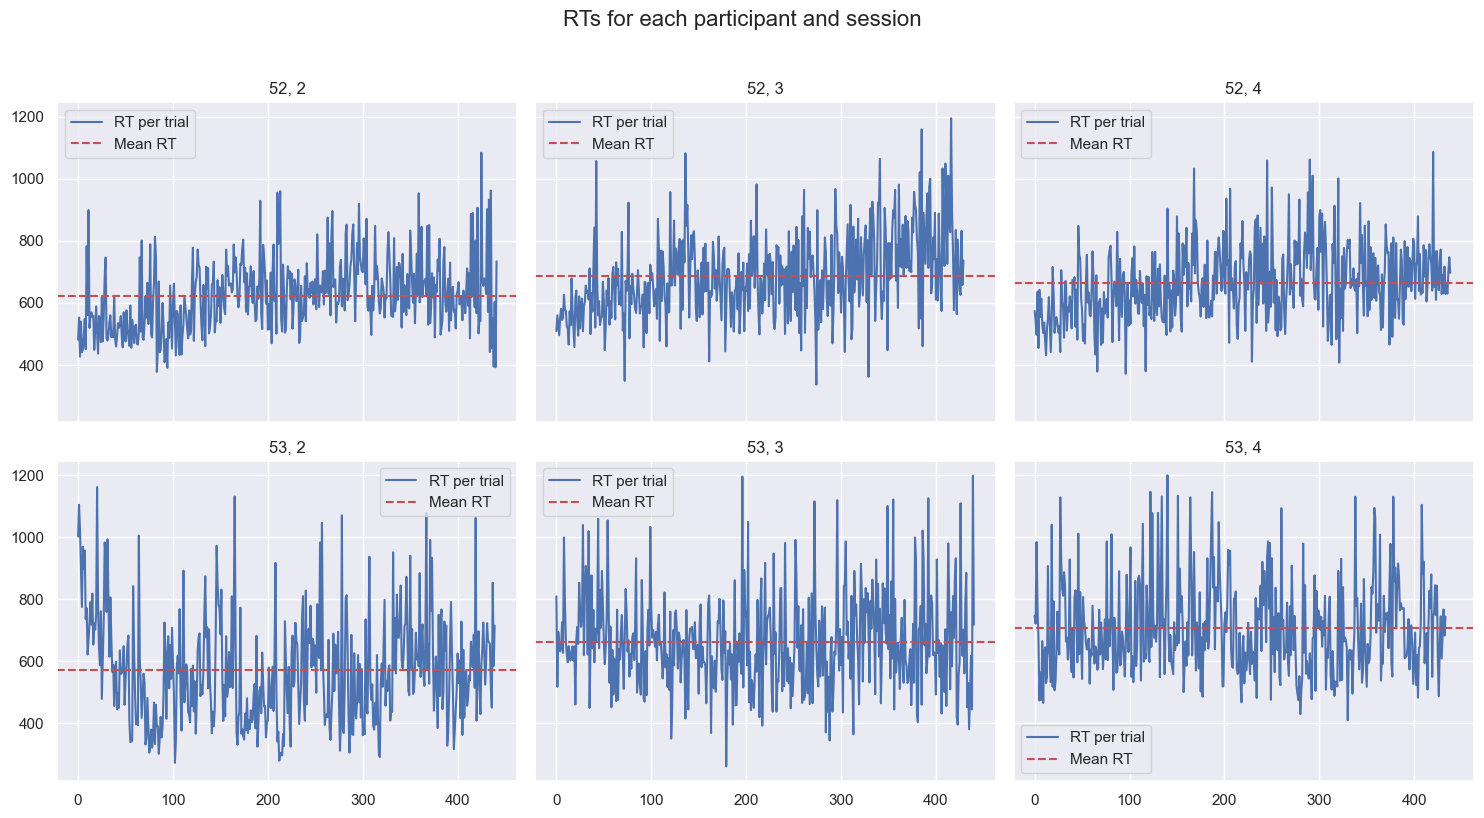

In [13]:
# Raw RT
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharex=True, sharey=True)
fig.suptitle('RTs for each participant and session', fontsize=16, y=1.02)

if n_rows == 1 or n_cols == 1:
    axes = np.array(axes).reshape(n_rows, n_cols)

## Loop through each combination of 'session' and 'subject_id' and create a plot
for i, session in enumerate(unique_sessions):
    for j, subject_id in enumerate(unique_subject_ids):
        ax_index = j * len(unique_sessions) + i
        ax = axes[j, i]

        ## Filter the dataframe for the current session and subject_id
        subset = combined_results_dataframe[(combined_results_dataframe['session'] == session) & (combined_results_dataframe['subject_id'] == subject_id)]

        ## Plot
        ax.plot(subset['RT_ms'].values, label=f'RT per trial')
        ax.axhline(subset['RT_ms'].mean(), color='r', linestyle='--', label='Mean RT')
        ax.set_title(f'{subject_id}, {session}')
        ax.legend()

## Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'RT_for_each_participant_and_session.pdf'))
plt.show()

# Check if they're sleepy

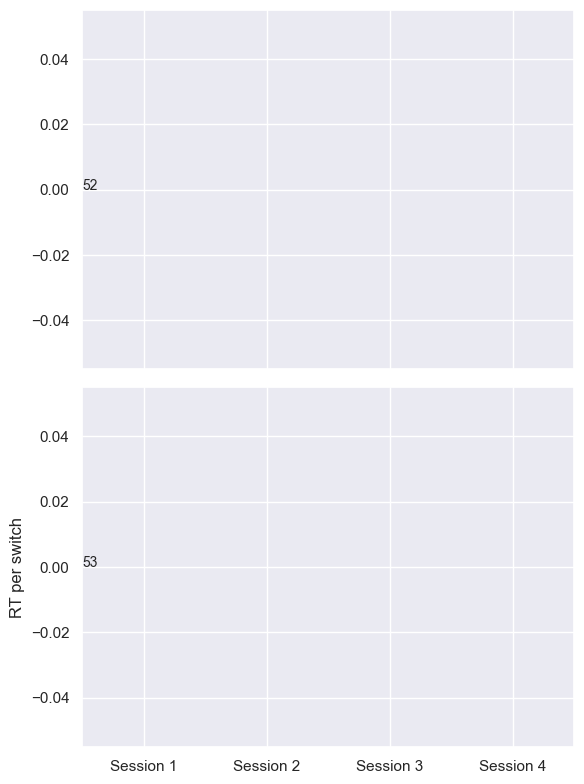

In [14]:
# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

fig, axes = plt.subplots(n_rows, 1, figsize=(6, n_rows*4), sharex=True, sharey=True)
if n_rows == 1:
    axes = np.array(axes).reshape(n_rows)

for i, subject_id in enumerate(unique_subject_ids):
    ax = axes[i]

    ## Filter the dataframe for the current session and subject_id
    dataframe_1 = combined_results_dataframe[(combined_results_dataframe['subject_id'] == subject_id) & (combined_results_dataframe['session'] == 'session-01')]
    list_1 = dataframe_1['RT_ms'].dropna().tolist()
    dataframe_2 = combined_results_dataframe[(combined_results_dataframe['subject_id'] == subject_id) & (combined_results_dataframe['session'] == 'session-02')]
    list_2 = dataframe_2['RT_ms'].dropna().tolist()
    dataframe_3 = combined_results_dataframe[(combined_results_dataframe['subject_id'] == subject_id) & (combined_results_dataframe['session'] == 'session-03')]
    list_3 = dataframe_3['RT_ms'].dropna().tolist()
    dataframe_4 = combined_results_dataframe[(combined_results_dataframe['subject_id'] == subject_id) & (combined_results_dataframe['session'] == 'session-04')]
    list_4 = dataframe_4['RT_ms'].dropna().tolist()
    valence_list = [list_1, list_2, list_3, list_4]

    # Boxplot data
    bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                    capprops=dict(color=c),
                    whiskerprops=dict(color=c),
                    flierprops=dict(color=c, markeredgecolor=c),
                    medianprops=dict(color=c))
    # Change to the desired color and add transparency
    for patch, color in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    for median in bp['medians']:
        median.set_color('black')

#    # Violinplot data (specify points as length data)
#    vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
#                       showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
#    # Change to the desired color
#    for idx, b in enumerate(vp['bodies']): # Slices it in half
#        # Change to the desired color
#        b.set_color(plot_colors[idx])

    # Scatterplot data
    for idx, features in enumerate(valence_list):
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + .75)
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
        x = out + 0.4
        ax.scatter(x, features, s=.3, c=plot_colors[idx])

    ax.text(0.5, 0, f'{subject_id}', fontsize=10)

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Session 1','Session 2','Session 3','Session 4'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_sleep_check'

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

# Check congruency, valence and volatility

In [15]:
# Remove non-response trials
print(combined_results_dataframe)
combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['response'].notna()]
print(combined_results_dataframe)

      trial  emotional_cue_time  response objectively_correct  \
0         8        1.769530e+09  approach               False   
1         9        1.769530e+09  approach               False   
2        10        1.769530e+09  approach                True   
3        11        1.769530e+09  approach                True   
4        12        1.769530e+09     avoid                True   
...     ...                 ...       ...                 ...   
2659    447        1.771438e+09     avoid                True   
2660    448        1.771438e+09  approach                True   
2661    449        1.771438e+09     avoid               False   
2662    450        1.771438e+09     avoid                True   
2663    451        1.771438e+09     avoid                True   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                   False   1.769530e+09  0.482   1.769530e+09             2   
1                   False   1.769530e+09  0.553   1.769530e

In [16]:
# Check a block's congruency
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe_with_volatility = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility)

dataframe_without_volatility = combined_results_dataframe

      trial  emotional_cue_time  response objectively_correct  \
0        10        1.769530e+09  approach                True   
1        11        1.769530e+09  approach                True   
2        13        1.769530e+09  approach                True   
3        14        1.769530e+09  approach                True   
4        16        1.769530e+09  approach                True   
...     ...                 ...       ...                 ...   
2621    442        1.771438e+09  approach                True   
2622    444        1.771438e+09  approach                True   
2623    445        1.771438e+09     avoid               False   
2624    448        1.771438e+09  approach                True   
2625    449        1.771438e+09     avoid               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                    True   1.769530e+09  0.427   1.769530e+09             1   
1                    True   1.769530e+09  0.540   1.769530e

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_8251/2462335281.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


In [17]:
print(dataframe_without_volatility[['trial','stimuli_type','probability_condition']])
print(dataframe_with_volatility[['trial','stimuli_type','probability_condition']])

      trial  stimuli_type  probability_condition
0         8             2                     80
1         9             2                     80
2        10             1                     20
3        11             1                     20
4        12             2                     80
...     ...           ...                    ...
2659    447             1                     80
2660    448             2                     20
2661    449             2                     20
2662    450             1                     80
2663    451             1                     80

[2626 rows x 3 columns]
      trial  stimuli_type  probability_condition
0        10             1                     20
1        11             1                     20
2        13             1                     20
3        14             1                     20
4        16             1                     20
...     ...           ...                    ...
2621    442             2                   

# Plot average RT for different groups
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility
- Valence/Congruency
- Valence/Congruency/Volatility

ValueError: zero-size array to reduction operation minimum which has no identity

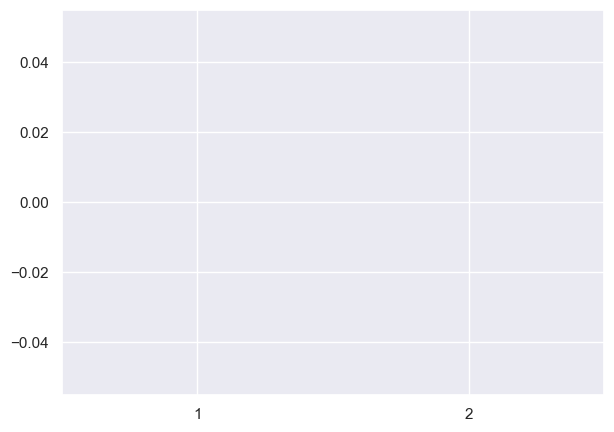

In [18]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['response'] == 'up']
happy_list = happy_dataframe['RT_ms'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['response'] == 'down']
angry_list = angry_dataframe['RT_ms'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['up', 'down'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_responses'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

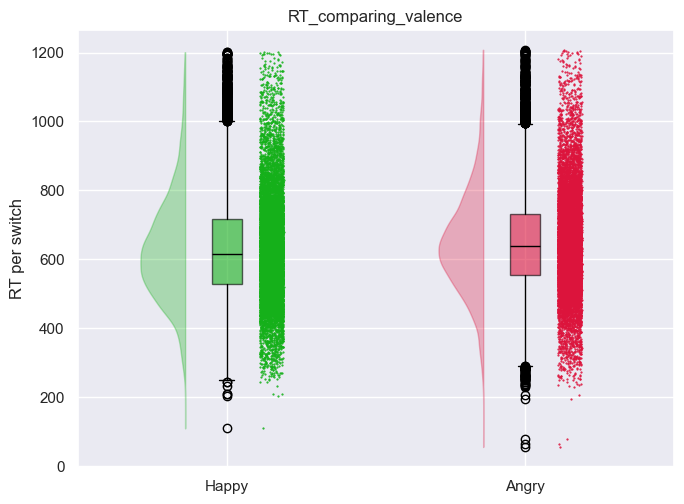

In [11]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['valence'] == 'happy']
happy_list = happy_dataframe['RT_ms'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['valence'] == 'angry']
angry_list = angry_dataframe['RT_ms'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Happy', 'Angry'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

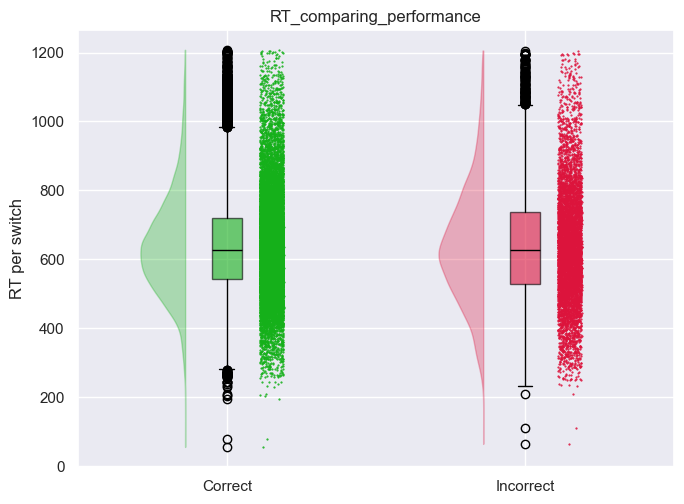

In [12]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['objectively_correct'] == 'True']
happy_list = happy_dataframe['RT_ms'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['objectively_correct'] == 'False']
angry_list = angry_dataframe['RT_ms'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Correct', 'Incorrect'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_performance'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

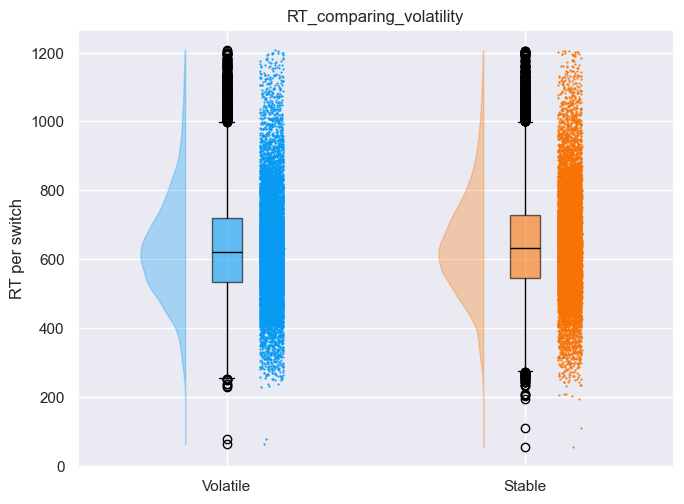

In [13]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['volatility'] == 'volatile']
happy_list = happy_dataframe['RT_ms'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['volatility'] == 'stable']
angry_list = angry_dataframe['RT_ms'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#069AF3', '#F97306']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Volatile', 'Stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

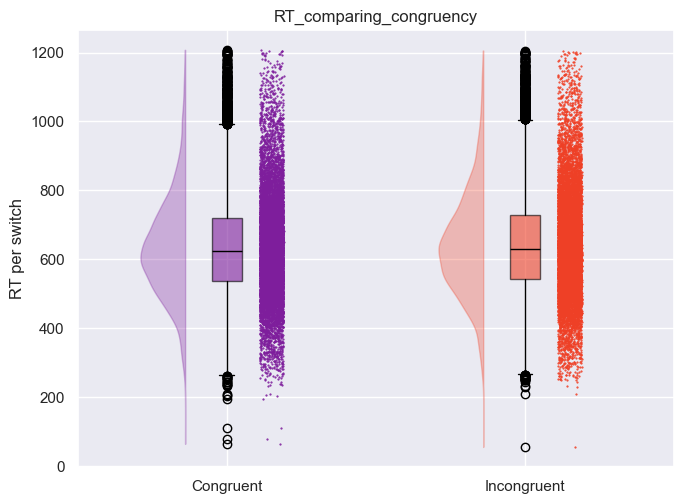

In [14]:
happy_dataframe = dataframe_with_volatility[dataframe_with_volatility['congruency'] == 'congruent']
happy_list = happy_dataframe['RT_ms'].dropna().tolist()
angry_dataframe = dataframe_with_volatility[dataframe_with_volatility['congruency'] == 'incongruent']
angry_list = angry_dataframe['RT_ms'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Congruent', 'Incongruent'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

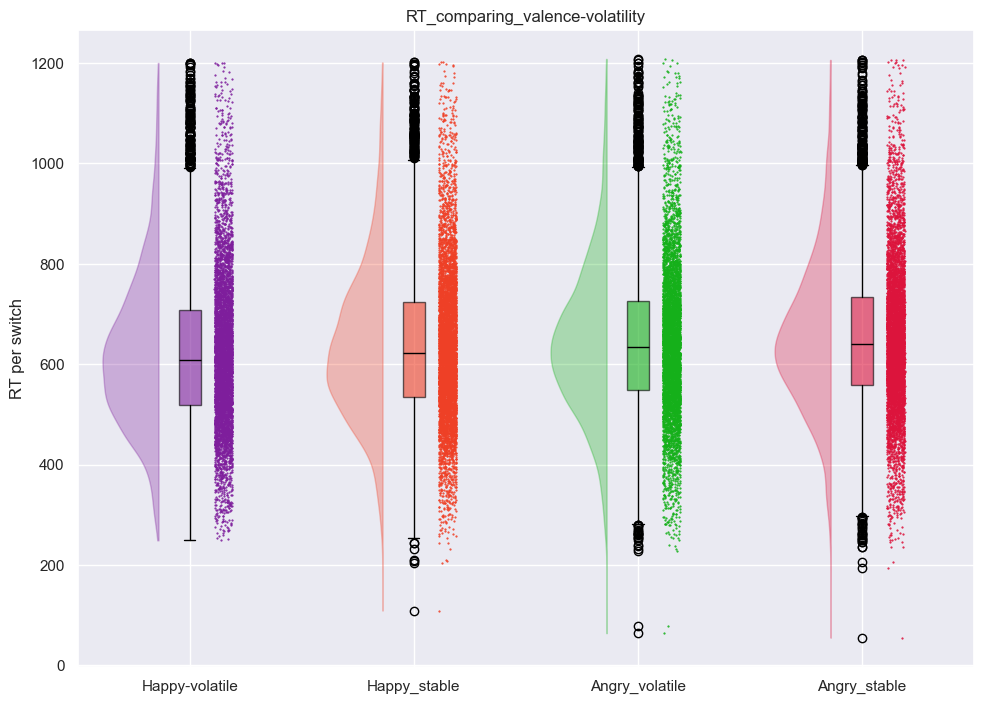

In [15]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_ms'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['volatility'] == 'stable')]
list_2 = dataframe_2['RT_ms'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_ms'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['volatility'] == 'stable')]
list_4 = dataframe_4['RT_ms'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Happy-volatile', 'Happy_stable', 'Angry_volatile', 'Angry_stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence-volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

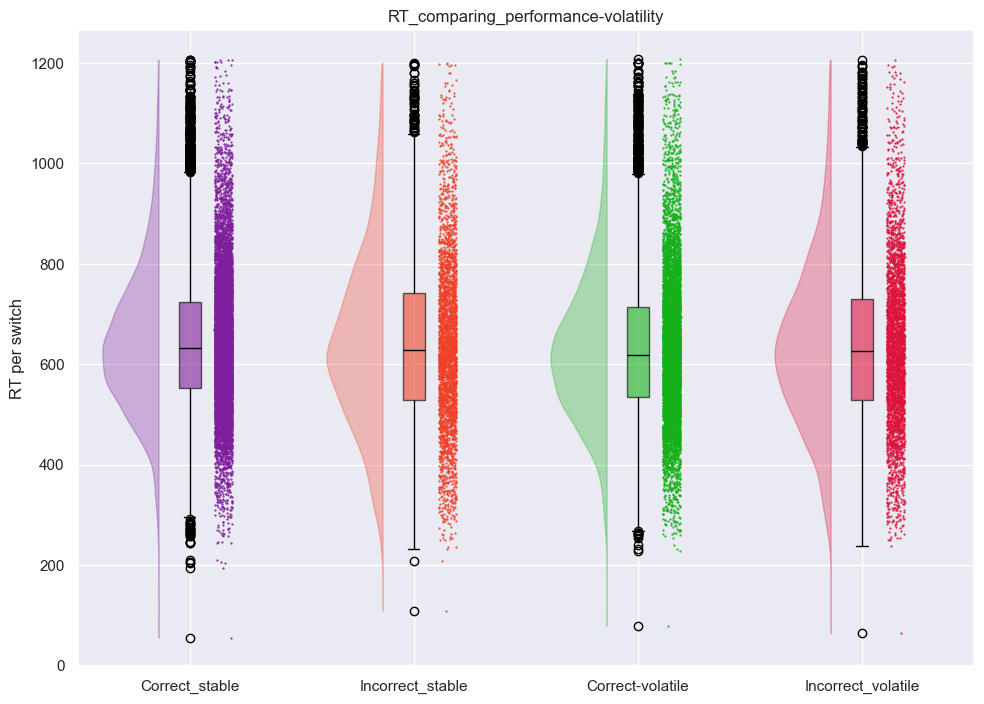

In [16]:
plt.show()
dataframe_1 = dataframe_with_volatility[
    (dataframe_with_volatility['objectively_correct'] == 'True') & (dataframe_with_volatility['volatility'] == 'stable')]
list_1 = dataframe_1['RT_ms'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[
    (dataframe_with_volatility['objectively_correct'] == 'False') & (dataframe_with_volatility['volatility'] == 'stable')]
list_2 = dataframe_2['RT_ms'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[
    (dataframe_with_volatility['objectively_correct'] == 'True') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_ms'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[
    (dataframe_with_volatility['objectively_correct'] == 'False') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_4 = dataframe_4['RT_ms'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist=True, vert=True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side='low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']):  # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1, 5, 1), ['Correct_stable', 'Incorrect_stable', 'Correct-volatile', 'Incorrect_volatile'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_performance-volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

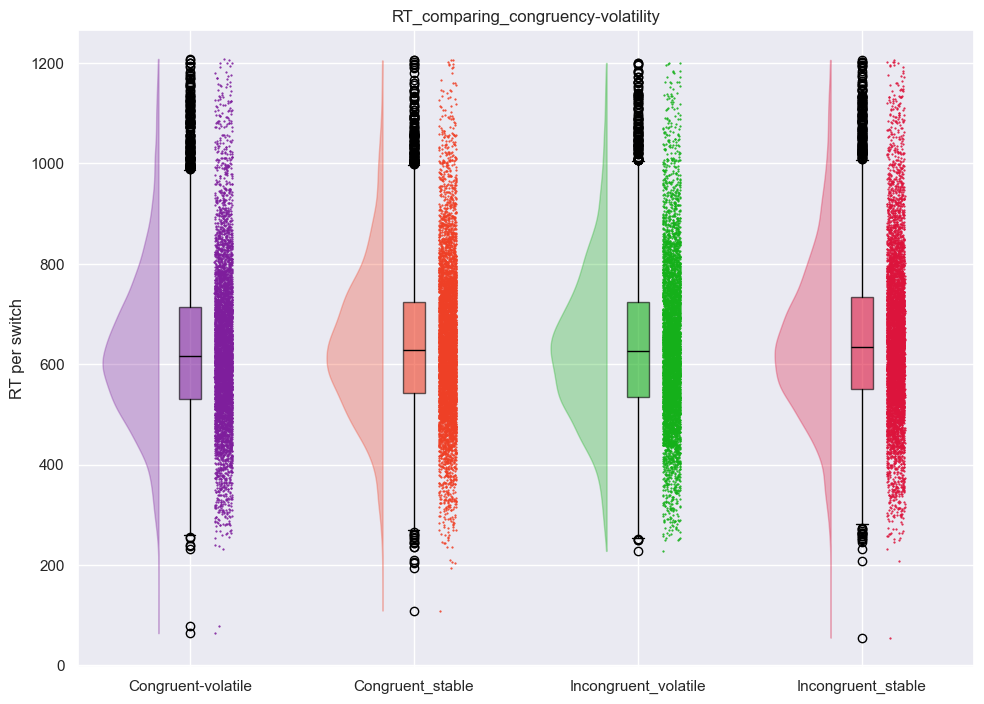

In [17]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_ms'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_2 = dataframe_2['RT_ms'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_ms'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_4 = dataframe_4['RT_ms'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Congruent-volatile', 'Congruent_stable', 'Incongruent_volatile', 'Incongruent_stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency-volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

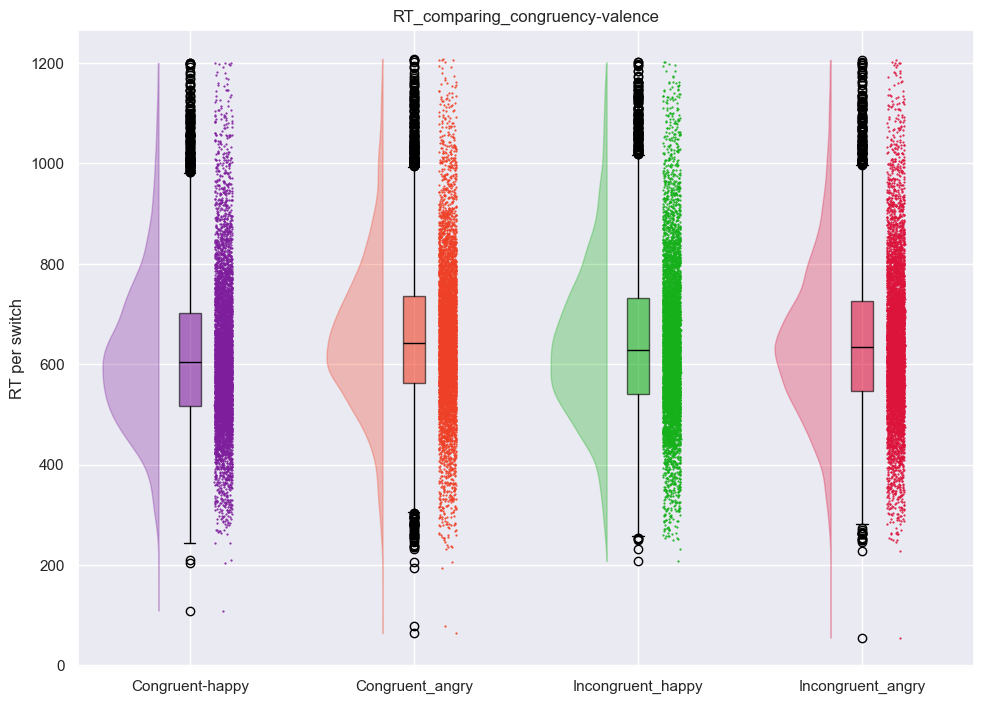

In [18]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['valence'] == 'happy')]
list_1 = dataframe_1['RT_ms'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['valence'] == 'angry')]
list_2 = dataframe_2['RT_ms'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['valence'] == 'happy')]
list_3 = dataframe_3['RT_ms'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['valence'] == 'angry')]
list_4 = dataframe_4['RT_ms'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Congruent-happy', 'Congruent_angry', 'Incongruent_happy', 'Incongruent_angry'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency-valence'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

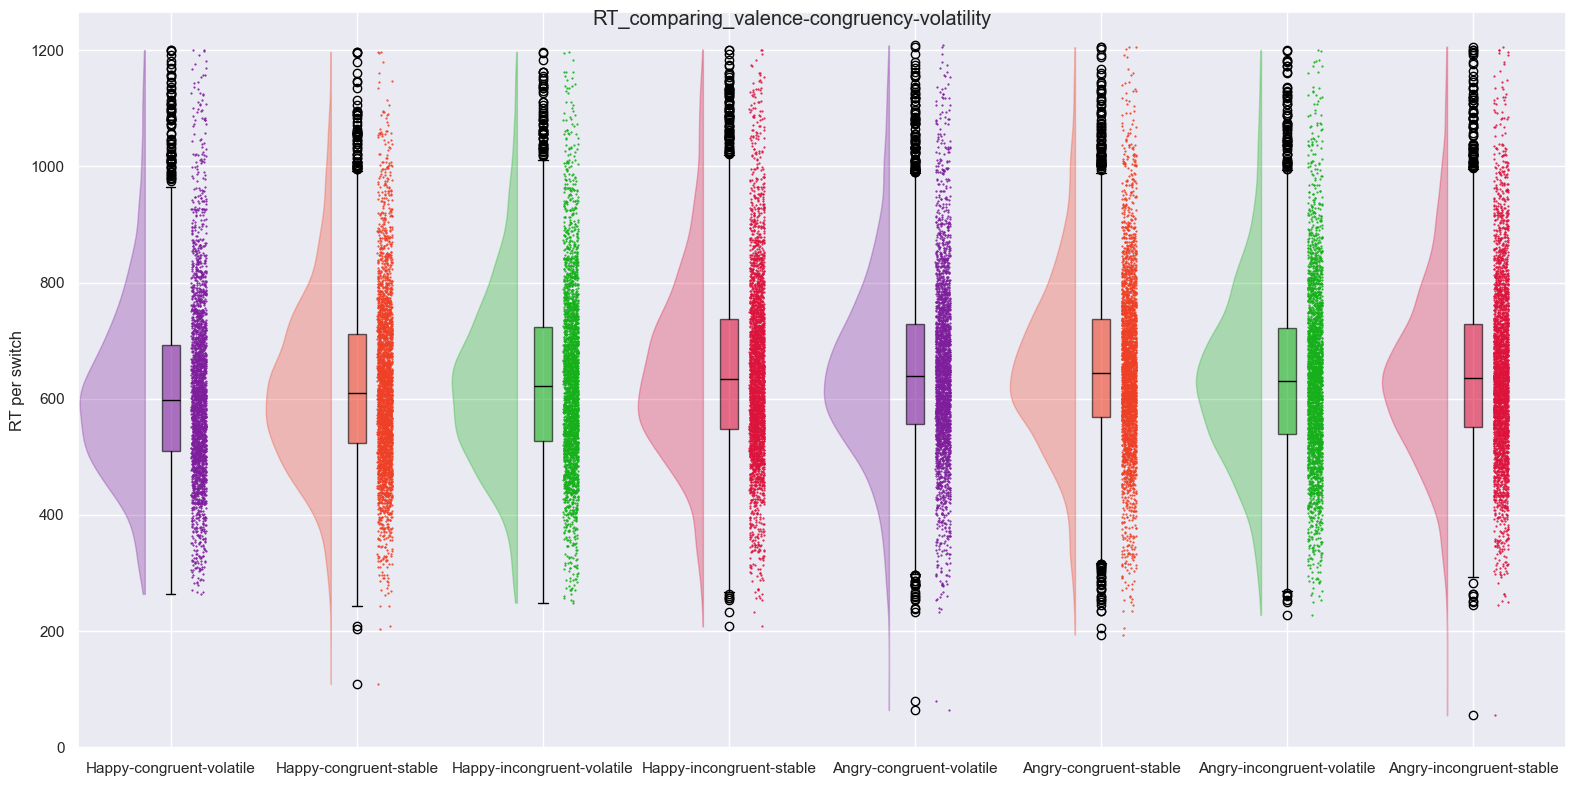

In [19]:
dataframe_1 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_ms'].dropna().tolist()
dataframe_2 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_2 = dataframe_2['RT_ms'].dropna().tolist()
dataframe_3 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_ms'].dropna().tolist()
dataframe_4 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'happy') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_4 = dataframe_4['RT_ms'].dropna().tolist()
dataframe_5 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_5 = dataframe_5['RT_ms'].dropna().tolist()
dataframe_6 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'congruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_6 = dataframe_6['RT_ms'].dropna().tolist()
dataframe_7 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'volatile')]
list_7 = dataframe_7['RT_ms'].dropna().tolist()
dataframe_8 = dataframe_with_volatility[(dataframe_with_volatility['valence'] == 'angry') & (dataframe_with_volatility['congruency'] == 'incongruent') & (dataframe_with_volatility['volatility'] == 'stable')]
list_8 = dataframe_8['RT_ms'].dropna().tolist()
valence_list = [list_1, list_2, list_3, list_4, list_5, list_6, list_7, list_8]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C', '#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86, 4.86, 5.86, 6.86, 7.86], widths=0.7,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,9,1), ['Happy-congruent-volatile', 'Happy-congruent-stable', 'Happy-incongruent-volatile', 'Happy-incongruent-stable', 'Angry-congruent-volatile', 'Angry-congruent-stable', 'Angry-incongruent-volatile', 'Angry-incongruent-stable', ])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence-congruency-volatility'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()